In [6]:
import pandas as pd
df = pd.read_csv("../data/cleaned/sms_spam_cleaned.csv")
print(df.shape)        # should be ~5500 rows
print(df.columns)
print(df['label'].value_counts())

(5169, 12)
Index(['label', 'text', 'label_num', 'clean_text', 'char_count', 'word_count',
       'clean_words', 'avg_word_len', 'url', 'number', 'exclaim_count',
       'uppercase_ratio'],
      dtype='str')
label
ham     4516
spam     653
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

label              0
text               0
label_num          0
clean_text         9
char_count         0
word_count         0
clean_words        0
avg_word_len       0
url                0
number             0
exclaim_count      0
uppercase_ratio    0
dtype: int64


In [8]:
df = df.dropna(subset=['clean_text'])

In [9]:
print(df.isnull().sum())

label              0
text               0
label_num          0
clean_text         0
char_count         0
word_count         0
clean_words        0
avg_word_len       0
url                0
number             0
exclaim_count      0
uppercase_ratio    0
dtype: int64


In [10]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X = df['clean_text']
y = df['label_num']

# Method 1: Count Vectorizer
cv = CountVectorizer()
X_cv = cv.fit_transform(X)

# Method 2: TF-IDF Vectorizer
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

X_cv_train, X_cv_test, y_train, y_test = train_test_split(X_cv, y, test_size=0.2, random_state=42)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


nb_model = MultinomialNB()
nb_model.fit(X_cv_train, y_train)

svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_tfidf_train, y_train)

lr_model = LogisticRegression()      # optional bonus
lr_model.fit(X_tfidf_train, y_train)

C:\Users\Ranjit\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [24]:
from sklearn.metrics import accuracy_score

results = {
    "Naive Bayes (CountVec)":  accuracy_score(y_test, nb_model.predict(X_cv_test)),
    "SVM (TF-IDF)":            accuracy_score(y_test, svm_model.predict(X_tfidf_test)),
    "Logistic Regression":     accuracy_score(y_test, lr_model.predict(X_tfidf_test)),
}
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

Naive Bayes (CountVec): 0.9671
SVM (TF-IDF): 0.9806
Logistic Regression: 0.9535


In [27]:
import pickle

with open("../models/spam_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)          # best model

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)              # vectorizer MUST be saved too

In [28]:
import pandas as pd

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

print(results_df)

results_df.to_csv("../reports/model_comparison.csv", index=False)

                    Model  Accuracy
0  Naive Bayes (CountVec)  0.967054
1            SVM (TF-IDF)  0.980620
2     Logistic Regression  0.953488


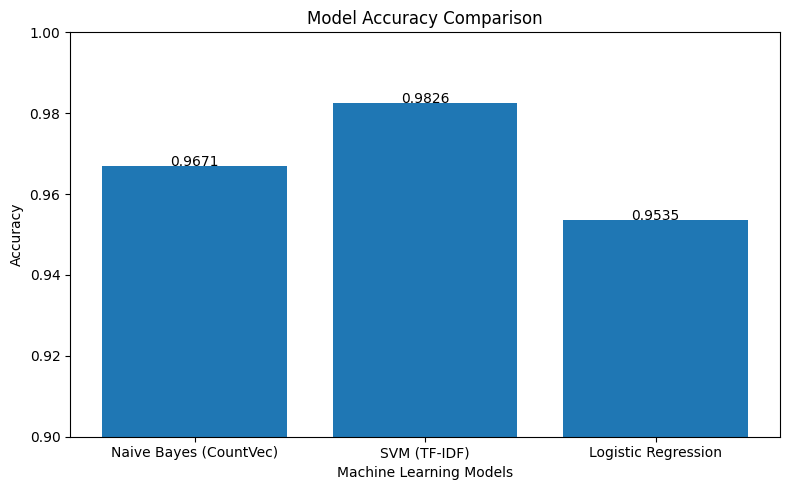

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)  # Zoom into the important range

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center'
    )

plt.tight_layout()
plt.savefig("../reports/model_accuracy_comparison.png")
plt.show()

In [18]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions using best model (SVM)
y_pred = svm_model.predict(X_tfidf_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Precision: 0.9824561403508771
Recall: 0.875
F1 Score: 0.9256198347107438

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       904
           1       0.98      0.88      0.93       128

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032



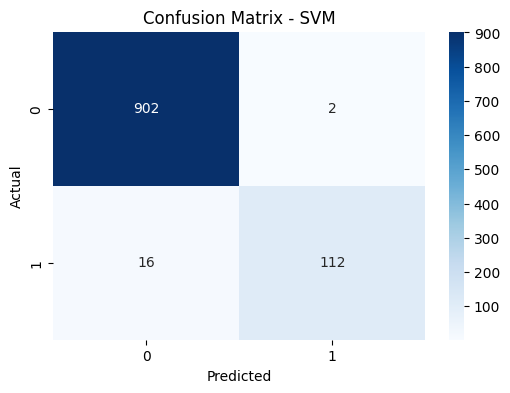

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../reports/confusion_matrix_svm.png")

plt.show()

In [29]:
test_msg = ["Congratulations! You won ₹50000"]

vector = tfidf.transform(test_msg)

print(svm_model.predict(vector))
print(svm_model.predict_proba(vector))

[0]
[[0.85498567 0.14501433]]
